# Mutation location vs. ΔΔG

**Scope.** This notebook is one of two pre-training, dataset-level exploratory analyses
named in Implementation Spec §5 (Metrics). It looks at the *raw dataset* before any model
exists: how does the measured ΔΔG (and the mix of `LabelType`s: bounded / ineq / n.b.)
vary across the structural classification of where the mutation sits at the
antibody-antigen interface?

A **separate** post-training version of this same analysis is implemented under
`dl/metrics/` and operates on trained-model *predictions* rather than the raw labels.
This notebook only ever looks at ground-truth data — no model is loaded or referenced here.

**Interface regions** (`InterfaceRegion` in `shared/constants.py`):
- `support` — interface residue that is buried in the complex but was already buried in
  the unbound state.
- `core` — interface residue buried only upon complex formation (classic "hot spot"
  territory).
- `rim` — interface residue at the periphery of the contact patch, partially exposed.
- `surface` — non-interface, solvent-exposed residue.
- `interior` — non-interface, buried residue (rare for SKEMPI antibody-antigen entries,
  included here for schema completeness).

**A note on the data below.** The real pre-processing pipeline (a separate, parallel
workstream) writes its output as the four per-split CSVs named in
`shared.constants.SPLIT_FILES`, and may not have produced them yet. So this notebook runs
end-to-end right now, it defaults to a small **synthetic** dataset generated to match the
`MutationRecord` schema exactly (see the "Data loading" section below for how to switch to
real data once it exists).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


def resolve_repo_root() -> Path:
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


def add_repo_root_to_sys_path() -> Path:
    repo_root = resolve_repo_root()
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    return repo_root


REPO_ROOT = add_repo_root_to_sys_path()


In [2]:
from shared.constants import InterfaceRegion, LabelType  # noqa: E402

sns.set_theme(style="whitegrid")

REGION_ORDER = [region.value for region in InterfaceRegion]
REGION_PALETTE = dict(zip(REGION_ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))
LABEL_TYPE_ORDER = [label_type.value for label_type in LabelType]


The fixed color-per-region mapping above (`REGION_PALETTE`) uses a colorblind-safe,
validated categorical palette, assigned in a fixed order so a given region always maps to
the same color across every plot in this notebook.

## Data loading

`notebooks.processed_data.load_processed_dataframe` reads and combines the four split CSVs in `shared.constants.SPLIT_FILES` (`held_out_pdb_train/val.csv`, `same_pdb_allowed_train/val.csv`) into a flat `pandas.DataFrame`, one row per point mutation (a multi-point SKEMPI entry is exploded into one row per mutated residue, each keeping its parent sample's ddG/label). See `notebooks/processed_data.py` for why it deduplicates by `sample_id` before exploding: the same underlying sample is assigned independently under both splitting schemes, so it is written out verbatim into two of the four files.

In [3]:
from notebooks.processed_data import load_processed_dataframe

df = load_processed_dataframe()

print(f"Loaded {len(df)} point-mutation rows")
df.head()

Loaded 2083 point-mutation rows


,sample_id,pdb_id,complex_name,label_type,ddg_kcal_mol,ddg_bin,ineq_direction,temperature_kelvin,chain_id,chain_role,wt_residue,mutant_residue,residue_position,insertion_code,aligned_interface_position,flat_residue_index,interface_region,is_alanine_scanning
0,1AHW_AB_C_DC178A_10,1AHW,Immunoglobulin fab 5G9 :: Tissue factor,bounded,-0.484593,4.0,NaN,298.0,C,antigen,D,A,178,NaN,167,594,rim,True
1,"1AHW_AB_C_IC152Q,TC154I,YC156T_2",1AHW,Immunoglobulin fab 5G9 :: Tissue factor,ineq,3.975705,NaN,>,298.0,C,antigen,I,Q,152,NaN,141,568,support,False
2,"1AHW_AB_C_IC152Q,TC154I,YC156T_2",1AHW,Immunoglobulin fab 5G9 :: Tissue factor,ineq,3.975705,NaN,>,298.0,C,antigen,T,I,154,NaN,143,570,support,False
3,"1AHW_AB_C_IC152Q,TC154I,YC156T_2",1AHW,Immunoglobulin fab 5G9 :: Tissue factor,ineq,3.975705,NaN,>,298.0,C,antigen,Y,T,156,NaN,145,572,core,False
4,"1AHW_AB_C_KC149A,DC150A_1",1AHW,Immunoglobulin fab 5G9 :: Tissue factor,bounded,1.181472,6.0,NaN,298.0,C,antigen,K,A,149,NaN,138,565,rim,True


## Sanity check: does the loaded data match the `MutationRecord` contract?

In [4]:
EXPECTED_MUTATION_RECORD_COLUMNS = {
    "sample_id", "pdb_id", "chain_id", "chain_role", "wt_residue", "mutant_residue",
    "residue_position", "label_type", "ddg_kcal_mol", "ddg_bin", "interface_region",
    "is_alanine_scanning",
}


def missing_mutation_record_columns(data: pd.DataFrame) -> set[str]:
    return EXPECTED_MUTATION_RECORD_COLUMNS - set(data.columns)


def assert_matches_mutation_record_schema(data: pd.DataFrame) -> None:
    missing = missing_mutation_record_columns(data)
    assert not missing, f"Loaded data is missing MutationRecord columns: {missing}"


assert_matches_mutation_record_schema(df)

print("Interface region counts:")
print(df["interface_region"].value_counts(dropna=False))
print("\nLabel type counts:")
print(df["label_type"].value_counts(dropna=False))
print(f"\nRecords with a numeric ddG value: {df['ddg_kcal_mol'].notna().sum()} / {len(df)}")


Interface region counts:
interface_region
core        578
rim         555
surface     486
support     307
interior    157
Name: count, dtype: int64

Label type counts:
label_type
bounded    1697
n.b.        228
ineq        158
Name: count, dtype: int64

Records with a numeric ddG value: 1855 / 2083


**`sample_id` is not a unique row key.** A SKEMPI entry that mutates several residues
at once (a multi-point mutant) is stored as multiple rows sharing one `sample_id` and one
measured `ddg_kcal_mol` — one row per mutated residue, each with its own
`interface_region`. Each row is still a single wt→mutant substitution at one position,
but its `ddg_kcal_mol` reflects the combined effect of the *whole* mutant complex, not
that residue's effect in isolation. This matters for the region-level analysis below: a
multi-point mutant that touches two different regions contributes the same ddG value to
both regions' distributions.

In [5]:
def rows_per_sample_id(data: pd.DataFrame) -> pd.Series:
    return data.groupby("sample_id").size()


def multi_point_mutation_row_count(data: pd.DataFrame) -> int:
    counts = rows_per_sample_id(data)
    multi_point_sample_ids = counts[counts > 1].index
    return int(data["sample_id"].isin(multi_point_sample_ids).sum())


print(f"Distinct measurements (unique sample_id): {df['sample_id'].nunique()}")
print(
    "Rows belonging to a multi-point-mutation measurement: "
    f"{multi_point_mutation_row_count(df)} / {len(df)}"
)


Distinct measurements (unique sample_id): 1057
Rows belonging to a multi-point-mutation measurement: 1374 / 2083


## Analysis 1a — ΔΔG distribution per interface region

Restricted to records that carry a numeric `ddg_kcal_mol` (bounded entries, plus any
ineq entries with a best-effort numeric bound). By SKEMPI convention, positive ΔΔG means
the mutation *weakens* binding (destabilizing); negative means it strengthens it.

In [6]:
def rows_with_numeric_ddg(data: pd.DataFrame) -> pd.DataFrame:
    return data[data["ddg_kcal_mol"].notna()].copy()


def categories_present(data: pd.DataFrame, column: str, order: list[str]) -> list[str]:
    return [category for category in order if category in data[column].unique()]


plot_df = rows_with_numeric_ddg(df)
regions_present = categories_present(plot_df, "interface_region", REGION_ORDER)


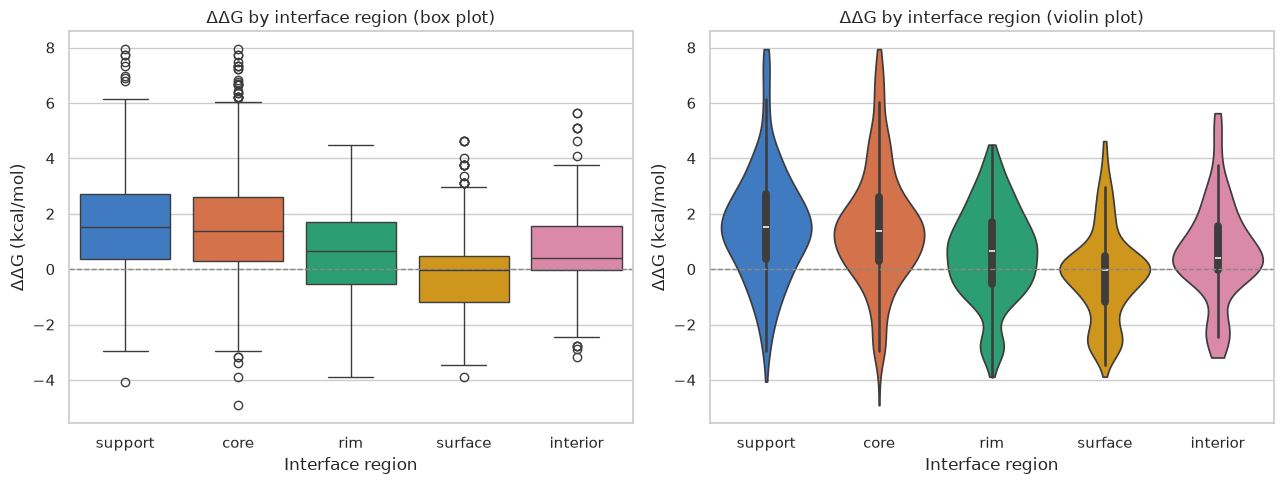

In [7]:
def plot_ddg_box_by_region(ax: plt.Axes, data: pd.DataFrame, order: list[str]) -> None:
    sns.boxplot(
        data=data, x="interface_region", y="ddg_kcal_mol", order=order,
        hue="interface_region", palette=REGION_PALETTE, legend=False, ax=ax,
    )
    ax.axhline(0, color="#898781", linewidth=1, linestyle="--")
    ax.set_title("ΔΔG by interface region (box plot)")
    ax.set_xlabel("Interface region")
    ax.set_ylabel("ΔΔG (kcal/mol)")


def plot_ddg_violin_by_region(ax: plt.Axes, data: pd.DataFrame, order: list[str]) -> None:
    sns.violinplot(
        data=data, x="interface_region", y="ddg_kcal_mol", order=order,
        hue="interface_region", palette=REGION_PALETTE, legend=False, ax=ax, cut=0,
    )
    ax.axhline(0, color="#898781", linewidth=1, linestyle="--")
    ax.set_title("ΔΔG by interface region (violin plot)")
    ax.set_xlabel("Interface region")
    ax.set_ylabel("ΔΔG (kcal/mol)")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_ddg_box_by_region(axes[0], plot_df, regions_present)
plot_ddg_violin_by_region(axes[1], plot_df, regions_present)
fig.tight_layout()
plt.show()


In [8]:
def summarize_ddg_by_region(data: pd.DataFrame, order: list[str]) -> pd.DataFrame:
    return (
        data.groupby("interface_region")["ddg_kcal_mol"]
        .agg(n="count", mean="mean", median="median", std="std")
        .reindex(order)
        .sort_values("mean", ascending=False)
    )


def ddg_values_by_region(data: pd.DataFrame, order: list[str]) -> list[pd.Series]:
    return [data.loc[data["interface_region"] == region, "ddg_kcal_mol"] for region in order]


def kruskal_wallis_across_regions(data: pd.DataFrame, order: list[str]) -> tuple[float, float]:
    """Distribution-free test for whether ddG differs across regions at all --
    robust to the non-normal, heavy-tailed shape typical of ddG data."""
    return stats.kruskal(*ddg_values_by_region(data, order))


def describe_region_extremes(summary: pd.DataFrame) -> str:
    highest, lowest = summary.index[0], summary.index[-1]
    return (
        f"In this dataset, '{highest}' has the highest mean ΔΔG "
        f"({summary.loc[highest, 'mean']:.2f} kcal/mol, n={int(summary.loc[highest, 'n'])}), "
        f"and '{lowest}' has the lowest ({summary.loc[lowest, 'mean']:.2f} kcal/mol, "
        f"n={int(summary.loc[lowest, 'n'])})."
    )


region_ddg_summary = summarize_ddg_by_region(plot_df, regions_present)
print(region_ddg_summary.round(3))

kw_stat, kw_p = kruskal_wallis_across_regions(plot_df, regions_present)
print(f"\nKruskal-Wallis across regions: H={kw_stat:.2f}, p={kw_p:.2e}")

print(f"\n{describe_region_extremes(region_ddg_summary)}")


                    n   mean  median    std
interface_region                           
support           262  1.555   1.511  2.035
core              517  1.529   1.358  2.151
interior          140  0.626   0.400  1.789
rim               486  0.562   0.640  1.702
surface           450 -0.191  -0.048  1.647

Kruskal-Wallis across regions: H=237.98, p=2.52e-50

In this dataset, 'support' has the highest mean ΔΔG (1.56 kcal/mol, n=262), and 'surface' has the lowest (-0.19 kcal/mol, n=450).


**Reading this.** The printed summary and Kruskal-Wallis test above are computed directly from real SKEMPI antibody-antigen records. Keep the multi-point-mutation caveat from the data-loading section in mind: the Kruskal-Wallis test treats every row as an independent observation, but a handful of shared ddG values appear more than once (once per residue touched) when a real SKEMPI entry mutated more than one residue at once.

## Analysis 1b — label type composition per interface region

Does the *mix* of bounded / ineq / n.b. labels shift across regions? For example, if
core mutations disproportionately abolish binding, we'd expect more `n.b.` (no binding
detected) entries there than on the surface.

label_type        bounded   ineq   n.b.
interface_region                       
support             0.821  0.033  0.147
core                0.791  0.104  0.106
rim                 0.807  0.068  0.124
surface             0.870  0.056  0.074
interior            0.745  0.146  0.108


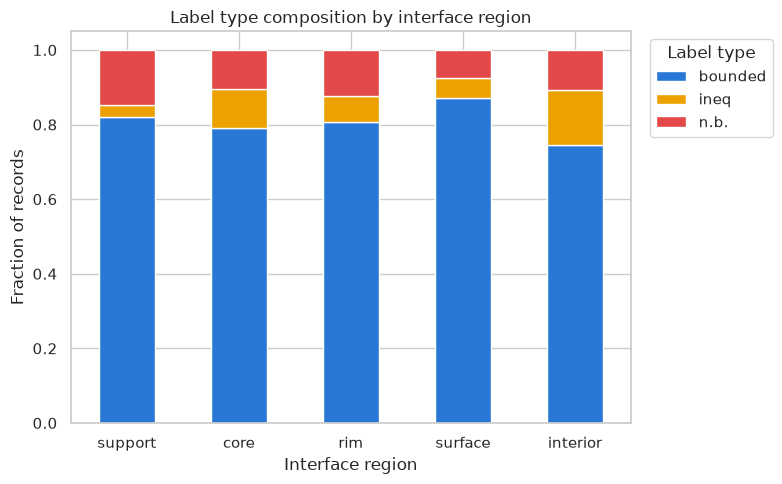

In [9]:
LABEL_PALETTE = {"bounded": "#2a78d6", "ineq": "#eda100", "n.b.": "#e34948"}


def label_type_composition_by_region(data: pd.DataFrame, region_order: list[str], label_order: list[str]) -> pd.DataFrame:
    return (
        data.groupby("interface_region")["label_type"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(index=region_order, columns=label_order)
    )


def plot_label_composition(composition: pd.DataFrame, palette: dict[str, str]) -> plt.Axes:
    ax = composition.plot(
        kind="bar", stacked=True, figsize=(8, 5),
        color=[palette.get(column, "#898781") for column in composition.columns],
    )
    ax.set_ylabel("Fraction of records")
    ax.set_xlabel("Interface region")
    ax.set_title("Label type composition by interface region")
    ax.legend(title="Label type", bbox_to_anchor=(1.02, 1), loc="upper left")
    return ax


label_types_present = categories_present(df, "label_type", LABEL_TYPE_ORDER)
composition = label_type_composition_by_region(df, regions_present, label_types_present)
print(composition.round(3))

plot_label_composition(composition, LABEL_PALETTE)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Summary

This notebook computes, per interface region:
- the ΔΔG distribution (box + violin plots, plus mean/median/std and a Kruskal-Wallis test for whether the regions differ at all), and
- the composition of `label_type` (bounded / ineq / n.b.).

Both are read directly off real SKEMPI antibody-antigen records via `notebooks.processed_data.load_processed_dataframe`.